In [2]:
import pandas as pd

In [3]:
pib = pd.read_csv('data_2025/pib2020-2025.csv')
who = pd.read_csv('data_2025/WHO_life_expectancy.csv')
pib.head()

,Country,2020,2021,2022,2023,2024,2025
0,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN
1,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0
2,Algeria,164774,185850.0,225709.0,247789.0,264913.0,268885.0
3,Andorra,2885,3325.0,3376.0,3786.0,4038.0,4035.0
4,Angola,66521,84375.0,142442.0,109764.0,115946.0,113343.0


In [4]:
pib.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  196 non-null    object 
 1   2020     196 non-null    int64  
 2   2021     194 non-null    float64
 3   2022     194 non-null    float64
 4   2023     194 non-null    float64
 5   2024     192 non-null    float64
 6   2025     189 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 10.8+ KB


In [5]:
cols = ['2021', '2022', '2023', '2024', '2025']
for col in cols:
    pib[col] = pib[col].fillna(pib[col].mean())
pib.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  196 non-null    object 
 1   2020     196 non-null    int64  
 2   2021     196 non-null    float64
 3   2022     196 non-null    float64
 4   2023     196 non-null    float64
 5   2024     196 non-null    float64
 6   2025     196 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 10.8+ KB


In [6]:
duplicates = pib.duplicated(keep=False)
dups = pib[duplicates]
dups

,Country,2020,2021,2022,2023,2024,2025


In [7]:
colis = ['2020','2021', '2022', '2023', '2024', '2025']
for col in colis:

    # Calcular el primer y tercer cuartil (Q1 y Q3) y el IQR
    Q1 = pib[col].quantile(0.25)
    Q3 = pib[col].quantile(0.75)
    IQR = Q3 - Q1

    # Definir los límites inferior y superior para los outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identificar los outliers
    outliers = pib[(pib[col] < lower_bound) | (pib[col] > upper_bound)]

    # Mostrar los outliers
    print(outliers)

            Country      2020        2021        2022        2023        2024  \
9         Australia   1362613   1655843.0   1725461.0   1742461.0   1796805.0   
17          Belgium    529269    598892.0    593906.0    644968.0    664965.0   
24           Brazil   1476092   1670650.0   1951849.0   2191137.0   2171337.0   
32           Canada   1655685   2022382.0   2190411.0   2173340.0   2241253.0   
36            China  15103357  18190803.0  18307816.0  18270351.0  18748009.0   
60           France   2645806   2968405.0   2797049.0   3056880.0   3162023.0   
64          Germany   3936989   4351188.0   4166872.0   4527009.0   4658526.0   
77            India   2674852   3167271.0   3346107.0   3638490.0   3909097.0   
78        Indonesia   1059055   1186510.0   1319101.0   1371169.0   1396300.0   
83            Italy   1905956   2180656.0   2105722.0   2305271.0   2372059.0   
85            Japan   5054069   5039148.0   4262146.0   4213167.0   4026211.0   
90      South Korea   174445

In [8]:
pib.describe()

,2020,2021,2022,2023,2024,2025
count,1.960000e+02,1.960000e+02,1.960000e+02,1.960000e+02,1.960000e+02,1.960000e+02
mean,4.378886e+05,5.043504e+05,5.255064e+05,5.486173e+05,5.756871e+05,5.991414e+05
std,1.942936e+06,2.209445e+06,2.335814e+06,2.440428e+06,2.546660e+06,2.644636e+06
min,5.200000e+01,6.200000e+01,6.100000e+01,6.300000e+01,6.500000e+01,6.500000e+01
25%,9.588000e+03,1.129325e+04,1.282200e+04,1.393550e+04,1.407425e+04,1.481975e+04
50%,3.533450e+04,3.908000e+04,4.261700e+04,4.471100e+04,4.929300e+04,5.605650e+04
75%,2.074810e+05,2.874108e+05,2.902762e+05,3.051838e+05,3.338902e+05,3.505675e+05
max,2.135412e+07,2.368118e+07,2.600690e+07,2.772072e+07,2.918490e+07,3.050722e+07


In [9]:
who.head()

,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Dim1,Value
0,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Male,48.7 [47.8-49.7]
1,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,CAF,Central African Republic,Year,2021,Sex,Male,49.6 [48.5-50.9]
2,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Both sexes,51.5 [50.5-52.6]
3,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,SWZ,Eswatini,Year,2021,Sex,Male,51.6 [50.7-52.8]
4,WHOSIS_000001,Life expectancy at birth (years),EMR,Eastern Mediterranean,Country,SOM,Somalia,Year,2021,Sex,Male,51.7 [50.6-53.1]


In [10]:
who.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24420 entries, 0 to 24419
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   IndicatorCode        24420 non-null  object
 1   Indicator            24420 non-null  object
 2   ParentLocationCode   24420 non-null  object
 3   ParentLocation       24420 non-null  object
 4   Location type        24420 non-null  object
 5   SpatialDimValueCode  24420 non-null  object
 6   Location             24420 non-null  object
 7   Period type          24420 non-null  object
 8   Period               24420 non-null  int64 
 9   Dim1 type            24420 non-null  object
 10  Dim1                 24420 non-null  object
 11  Value                24420 non-null  object
dtypes: int64(1), object(11)
memory usage: 2.2+ MB


In [11]:
who.isna()

,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Dim1,Value
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
24415,False,False,False,False,False,False,False,False,False,False,False,False
24416,False,False,False,False,False,False,False,False,False,False,False,False
24417,False,False,False,False,False,False,False,False,False,False,False,False
24418,False,False,False,False,False,False,False,False,False,False,False,False


In [12]:
duplicates = who.duplicated(keep=False)
dups = who[duplicates]
dups

,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Dim1,Value


In [13]:
who['IndicatorCode'].unique()
who['Indicator'].unique()
who['ParentLocationCode'].unique()
who['ParentLocation'].unique()
who['Location type'].unique()
who['Period type'].unique()
who['Dim1 type'].unique()
who['Dim1'].unique()

array(['Male', 'Both sexes', 'Female'], dtype=object)

In [14]:
who['IndicatorCode'] = who['IndicatorCode'].astype('category')
who['Indicator'] = who['Indicator'].astype('category')
who['ParentLocationCode'] = who['ParentLocationCode'].astype('category')
who['ParentLocation'] = who['ParentLocation'].astype('category')
who['Location type'] = who['Location type'].astype('category')
who['Period type'] = who['Period type'].astype('category')
who['Dim1 type'] = who['Dim1 type'].astype('category')
who['Dim1'] = who['Dim1'].astype('category')
who.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24420 entries, 0 to 24419
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   IndicatorCode        24420 non-null  category
 1   Indicator            24420 non-null  category
 2   ParentLocationCode   24420 non-null  category
 3   ParentLocation       24420 non-null  category
 4   Location type        24420 non-null  category
 5   SpatialDimValueCode  24420 non-null  object  
 6   Location             24420 non-null  object  
 7   Period type          24420 non-null  category
 8   Period               24420 non-null  int64   
 9   Dim1 type            24420 non-null  category
 10  Dim1                 24420 non-null  category
 11  Value                24420 non-null  object  
dtypes: category(8), int64(1), object(3)
memory usage: 955.2+ KB


In [15]:
who['Value_numeric'] = who['Value'].str.extract(r'(\d+\.?\d*)').astype(float)
print(who[['Value', 'Value_numeric']].head())

              Value  Value_numeric
0  48.7 [47.8-49.7]           48.7
1  49.6 [48.5-50.9]           49.6
2  51.5 [50.5-52.6]           51.5
3  51.6 [50.7-52.8]           51.6
4  51.7 [50.6-53.1]           51.7


In [16]:
esp_alb_2021 = who[(who['Period'] == 2021) & (who['Location'] == 'Albania')]
esp_alb_2021.head()

,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Dim1,Value,Value_numeric
348,WHOSIS_000001,Life expectancy at birth (years),EUR,Europe,Country,ALB,Albania,Year,2021,Sex,Male,74.4 [73.9-74.9],74.4
405,WHOSIS_000001,Life expectancy at birth (years),EUR,Europe,Country,ALB,Albania,Year,2021,Sex,Both sexes,76.4 [76.1-76.9],76.4
455,WHOSIS_000001,Life expectancy at birth (years),EUR,Europe,Country,ALB,Albania,Year,2021,Sex,Female,78.6 [78.4-79.0],78.6
867,WHOSIS_000015,Life expectancy at age 60 (years),EUR,Europe,Country,ALB,Albania,Year,2021,Sex,Male,18.7 [18.1-19.1],18.7
927,WHOSIS_000015,Life expectancy at age 60 (years),EUR,Europe,Country,ALB,Albania,Year,2021,Sex,Both sexes,19.9 [19.6-20.4],19.9


In [17]:
who.describe()

,Period,Value_numeric
count,24420.000000,24420.000000
mean,2010.500000,44.592547
std,6.344419,26.456631
min,2000.000000,9.100000
25%,2005.000000,18.800000
50%,2010.500000,32.850000
75%,2016.000000,71.900000
max,2021.000000,87.400000


In [18]:
df_21 = who[(who['Period'] == 2021) & (who['Indicator'] == 'Life expectancy at birth (years)')]
mi = df_21['Value_numeric'].min()
who[who['Value_numeric'] == mi]

,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Dim1,Value,Value_numeric
0,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Male,48.7 [47.8-49.7],48.7
7773,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2014,Sex,Both sexes,48.7 [47.3-49.9],48.7
17775,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,ZMB,Zambia,Year,2005,Sex,Male,48.7 [47.7-49.7],48.7
18887,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,MWI,Malawi,Year,2004,Sex,Female,48.7 [47.5-50.0],48.7


In [19]:
df_21 = who[(who['Period'] == 2021) & (who['Indicator'] == 'Life expectancy at birth (years)')]
ma = df_21['Value_numeric'].max()
who[who['Value_numeric'] == ma]

,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Dim1,Value,Value_numeric
554,WHOSIS_000001,Life expectancy at birth (years),WPR,Western Pacific,Country,JPN,Japan,Year,2021,Sex,Female,87.2 [87.2-87.2],87.2
2774,WHOSIS_000001,Life expectancy at birth (years),WPR,Western Pacific,Country,JPN,Japan,Year,2019,Sex,Female,87.2 [87.1-87.2],87.2


In [20]:
pib['2021'].mean()

np.float64(504350.4381443299)

In [21]:
df21 = who[who['Period'] == 2021]

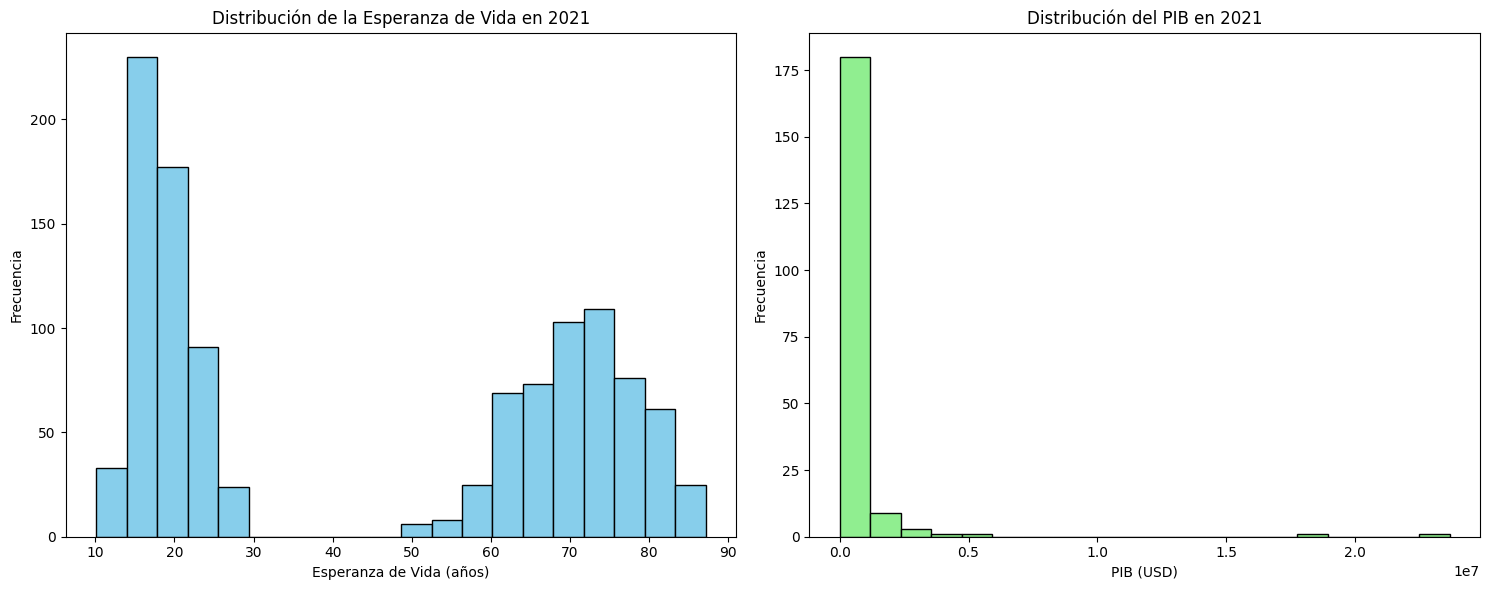

In [22]:
import matplotlib.pyplot as plt

# Crear los histogramas de Esperanza de vida y PIB para 2021
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histograma de Esperanza de vida en 2021
axes[0].hist(df21['Value_numeric'], bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Distribución de la Esperanza de Vida en 2021')
axes[0].set_xlabel('Esperanza de Vida (años)')
axes[0].set_ylabel('Frecuencia')

# Histograma de PIB en 2021
axes[1].hist(pib['2021'], bins=20, color='lightgreen', edgecolor='black')
axes[1].set_title('Distribución del PIB en 2021')
axes[1].set_xlabel('PIB (USD)')
axes[1].set_ylabel('Frecuencia')

# Mostrar los gráficos
plt.tight_layout()
plt.show()


In [23]:
corr = pib['2021'].corr(df21['Value_numeric'])
print(corr)

0.04015560850397477


In [24]:
numerical_data = pib.select_dtypes(include=[float, int])
# Calcular la correlación entre las columnas numéricas
correlacion = numerical_data.corr()
# Mostrar la matriz de correlación
correlacion

,2020,2021,2022,2023,2024,2025
2020,1.000000,0.998710,0.997605,0.996823,0.995298,0.994569
2021,0.998710,1.000000,0.998275,0.996440,0.994747,0.993673
2022,0.997605,0.998275,1.000000,0.999333,0.998452,0.997698
2023,0.996823,0.996440,0.999333,1.000000,0.999585,0.999088
2024,0.995298,0.994747,0.998452,0.999585,1.000000,0.999666
2025,0.994569,0.993673,0.997698,0.999088,0.999666,1.000000


In [25]:
who['Country'] = who['Location']
who['Year'] = who['Period']
who['Year'] = who['Year'].astype('str')

In [43]:
# Reestructurar el DataFrame PIB para convertir los años en una columna 'Year' y sus valores en la columna 'PIB'
pib_melted = pib.melt(id_vars=['Country'], value_vars=['2020', '2021', '2022', '2023', '2024', '2025'], 
                      var_name='Year', value_name='PIB')
# Convertir la columna 'Year' de ambos DataFrames a tipo string
pib_melted['Year'] = pib_melted['Year'].astype(str)

# Ahora proceder con el merge
df_combined = pd.merge(pib_melted, who, how='inner', on=['Country', 'Year'])


# Filtrar los datos de WHO para tener solo los registros con el año en la columna 'Period'
df_life = who[['Country', 'Year', 'Value_numeric', 'Dim1']]  # Filtramos solo las columnas relevantes

# Renombrar 'Period' a 'Year' en WHO para hacer el merge más claro
df_life = df_life.rename(columns={'Value_numeric': 'Esperanza_de_vida'})

# Unir ambos DataFrames por 'Country' y 'Year'
df_combined = pd.merge(pib_melted, df_life, how='inner', on=['Country', 'Year'])

# Ver los primeros registros del DataFrame combinado
df_combined.head()


,Country,Year,PIB,Esperanza_de_vida,Dim1
0,Afghanistan,2020,20136.0,59.3,Male
1,Afghanistan,2020,20136.0,60.5,Both sexes
2,Afghanistan,2020,20136.0,61.7,Female
3,Afghanistan,2020,20136.0,13.6,Male
4,Afghanistan,2020,20136.0,13.8,Both sexes


In [27]:
# Reestructurar el DataFrame PIB para tener los años como una columna
pib_melted = pib.melt(id_vars=['Country'], value_vars=['2021', '2022', '2023', '2024', '2025'], 
                      var_name='Year', value_name='PIB')

# Ver los primeros registros del DataFrame PIB reestructurado
print(pib_melted.head())

# Filtrar los datos de WHO para 2021 (puedes usar otros años si lo prefieres)
df_life_2021 = who[who['Period'] == 2021]

# Unir el DataFrame de PIB con el de WHO por país y año
df_combined = pd.merge(pib_melted, df_life_2021[['Country', 'Value_numeric', 'Year']], 
                       how='inner', left_on=['Country', 'Year'], right_on=['Country', 'Year'])

# Renombrar las columnas para hacerlas más claras
df_combined = df_combined.rename(columns={'Value_numeric': 'Esperanza_de_vida'})

# Ver los primeros registros del DataFrame combinado
df_combined.head()


       Country  Year       PIB
0  Afghanistan  2021   14278.0
1      Albania  2021   18086.0
2      Algeria  2021  185850.0
3      Andorra  2021    3325.0
4       Angola  2021   84375.0


,Country,Year,PIB,Esperanza_de_vida
0,Afghanistan,2021,14278.0,57.4
1,Afghanistan,2021,14278.0,59.1
2,Afghanistan,2021,14278.0,61.0
3,Afghanistan,2021,14278.0,13.6
4,Afghanistan,2021,14278.0,13.7


In [28]:
df_combined.info()
df_combined['PIB'] = df_combined['PIB'].fillna(df_combined['PIB'].mean())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 966 entries, 0 to 965
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            966 non-null    object 
 1   Year               966 non-null    object 
 2   PIB                966 non-null    float64
 3   Esperanza_de_vida  966 non-null    float64
dtypes: float64(2), object(2)
memory usage: 30.3+ KB


26.78270465529767
0.0015714962994494153
Coeficientes: [6.64108135e-07]
Intercepto: 44.507292766276855


C:\Users\Equipo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


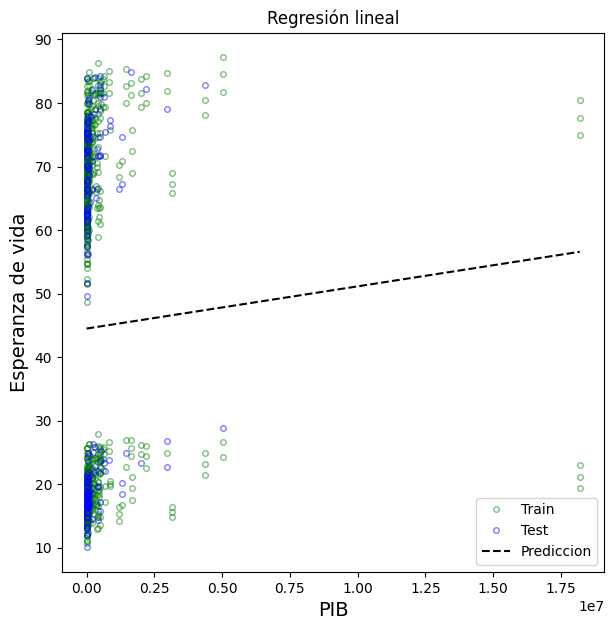

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Definir las variables dependiente e independiente
X = df_combined[['PIB']]  # Variable independiente
y = df_combined['Esperanza_de_vida']  # Variable dependiente

# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # test_size 0.2 son 20% de prueba, random_state numero aleatorio para empezar

# Crear el modelo de regresión lineal
model = LinearRegression()

# Entrenar el modelo
model.fit(X_train, y_train)

# Hacer predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# rmse r2 
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)


# Coeficientes e intercepto
coef = model.coef_
intercept = model.intercept_

print(rmse)
print(r2)
print("Coeficientes:", coef) # si es positivo, mientras mayor sea la variable ind mayor es la dep
print("Intercepto:", intercept) # interceto en x, ind = 0 


# graficar
linreg = LinearRegression()
linreg.fit(X_train, y_train)
fig1, ax = plt.subplots(1,1, figsize=(7,7))

ax.plot(X_train, y_train,'o', markersize=4, mec='green', mfc='None', label='Train', alpha=0.5) 
ax.plot(X_test, y_test,'o', markersize=4, mec='blue', mfc='None', label='Test', alpha=0.5) 

xgrid = np.linspace(np.min(X_train), np.max(X_train), 100)
ax.plot(xgrid, linreg.predict(xgrid.reshape(100, 1)), label='Prediccion', color='k', ls='--')
ax.set_title('Regresión lineal')
ax.set_xlabel('PIB', fontsize=14)
ax.set_ylabel('Esperanza de vida', fontsize=14)
ax.legend()



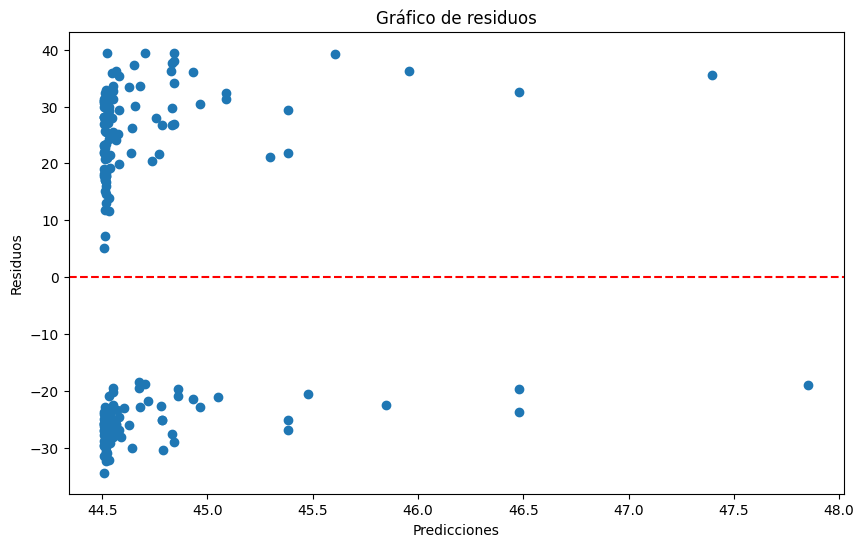

In [30]:
# Graficar los residuos
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Gráfico de residuos')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.show()


In [31]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Crear un transformador polinómico de grado 2
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

# Entrenar el modelo polinómico
model_poly = LinearRegression()
model_poly.fit(X_poly_train, y_train)

# Hacer predicciones con el modelo polinómico
y_pred_poly = model_poly.predict(X_poly_test)

# Evaluar el modelo polinómico
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print("RMSE (Polinómico):", rmse_poly)
print("R² (Polinómico):", r2_poly)


RMSE (Polinómico): 26.718398316160016
R² (Polinómico): 0.006360273465248811


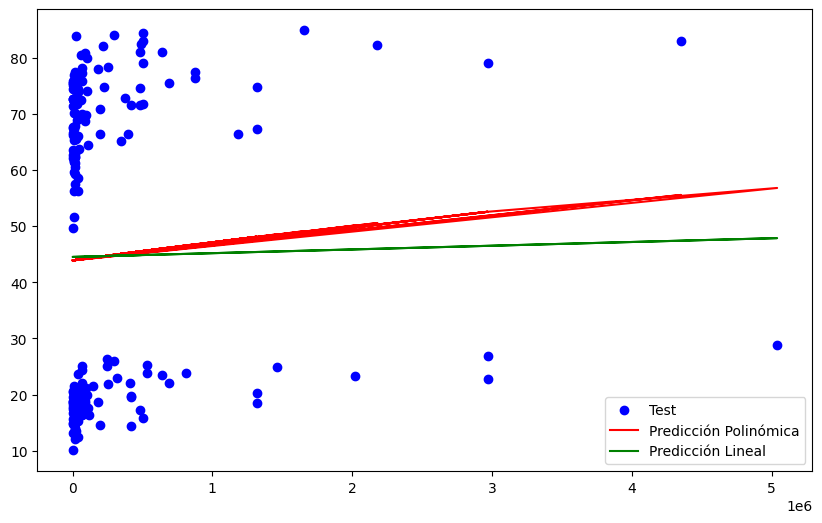

In [32]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Test')
plt.plot(X_test, y_pred_poly, color='red', label='Predicción Polinómica')
plt.plot(X_test, y_pred, color='green', label='Predicción Lineal')
plt.legend()
plt.show()


RMSE (Árbol de Decisión): 32.22968492787089
R² (Árbol de Decisión): -0.4458399698160074


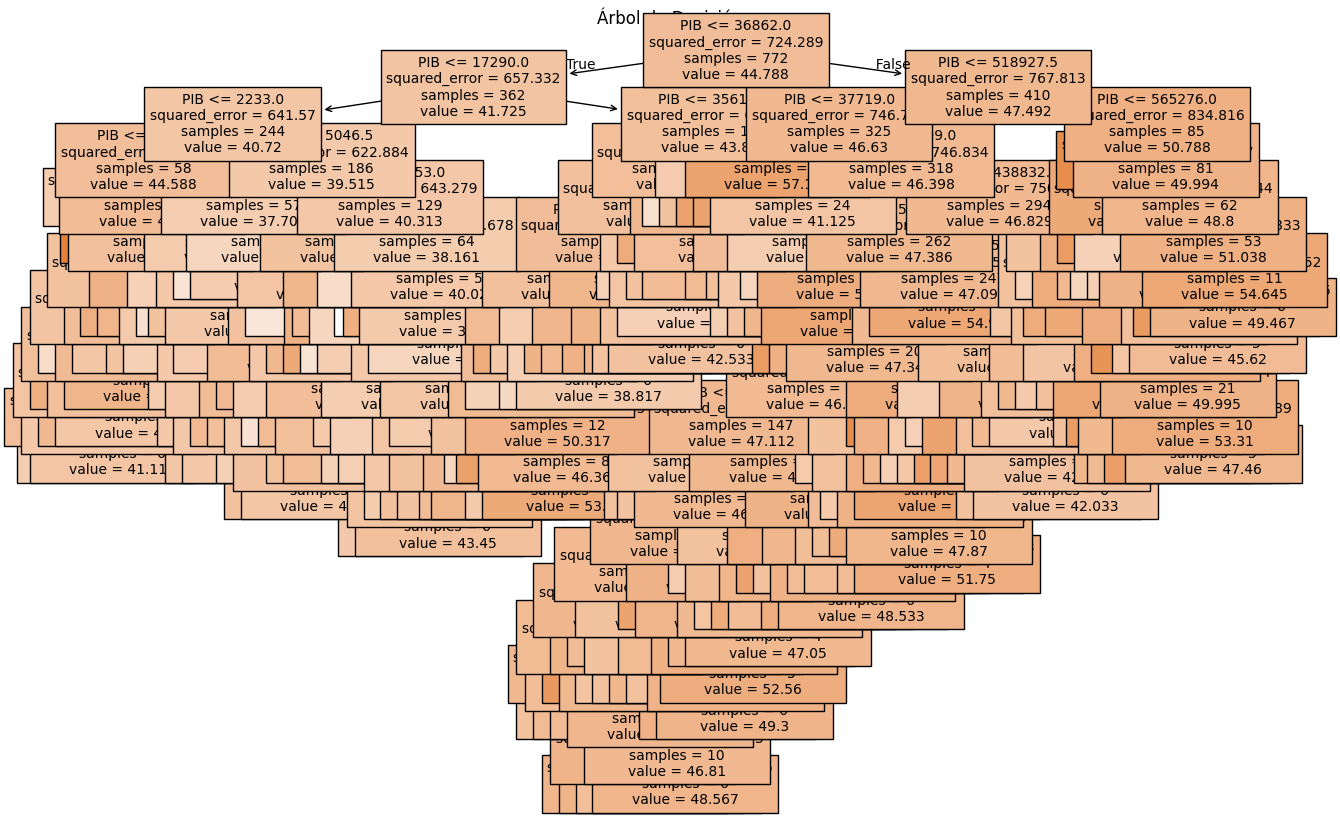

In [33]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Crear el modelo de Árbol de Decisión
tree_model = DecisionTreeRegressor(random_state=42)

# Entrenar el modelo
tree_model.fit(X_train, y_train)

# Hacer predicciones
y_pred_tree = tree_model.predict(X_test)

# Calcular RMSE y R²
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

print("RMSE (Árbol de Decisión):", rmse_tree)
print("R² (Árbol de Decisión):", r2_tree)

# Visualizar
from sklearn.tree import plot_tree

plt.figure(figsize=(15,10))
plot_tree(tree_model, filled=True, feature_names=['PIB'], fontsize=10)
plt.title("Árbol de Decisión")
plt.show()

In [34]:
from sklearn.ensemble import RandomForestRegressor

# Crear el modelo de Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Entrenar el modelo
rf_model.fit(X_train, y_train)

# Hacer predicciones
y_pred_rf = rf_model.predict(X_test)

# Calcular RMSE y R²
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("RMSE (Random Forest):", rmse_rf)
print("R² (Random Forest):", r2_rf)


RMSE (Random Forest): 32.1001671710015
R² (Random Forest): -0.4342428545486874


In [35]:
from sklearn.ensemble import RandomForestRegressor

# Crear el modelo de Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Entrenar el modelo
rf_model.fit(X_train, y_train)

# Hacer predicciones
y_pred_rf = rf_model.predict(X_test)

# Calcular RMSE y R²
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("RMSE (Random Forest):", rmse_rf)
print("R² (Random Forest):", r2_rf)

RMSE (Random Forest): 32.1001671710015
R² (Random Forest): -0.4342428545486874


In [36]:
from sklearn.neighbors import KNeighborsRegressor

# Crear el modelo KNN
knn_model = KNeighborsRegressor(n_neighbors=5)

# Entrenar el modelo
knn_model.fit(X_train, y_train)

# Hacer predicciones
y_pred_knn = knn_model.predict(X_test)

# Calcular RMSE y R²
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

print("RMSE (KNN):", rmse_knn)
print("R² (KNN):", r2_knn)


RMSE (KNN): 31.626112335272875
R² (KNN): -0.39219389523173254


In [37]:
from sklearn.svm import SVR

# Crear el modelo SVM
svm_model = SVR(kernel='rbf')

# Entrenar el modelo
svm_model.fit(X_train, y_train)

# Hacer predicciones
y_pred_svm = svm_model.predict(X_test)

# Calcular RMSE y R²
rmse_svm = np.sqrt(mean_squared_error(y_test, y_pred_svm))
r2_svm = r2_score(y_test, y_pred_svm)

print("RMSE (SVM):", rmse_svm)
print("R² (SVM):", r2_svm)

RMSE (SVM): 32.74696379876688
R² (SVM): -0.49262319454875736


In [38]:
models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'KNN', 'SVM']
rmse_scores = [rmse, rmse_tree, rmse_rf, rmse_knn, rmse_svm]
r2_scores = [r2, r2_tree, r2_rf, r2_knn, r2_svm]

# Crear un DataFrame para visualizar los resultados
import pandas as pd
results = pd.DataFrame({'Model': models, 'RMSE': rmse_scores, 'R²': r2_scores})

print(results)

               Model       RMSE        R²
0  Linear Regression  26.782705  0.001571
1      Decision Tree  32.229685 -0.445840
2      Random Forest  32.100167 -0.434243
3                KNN  31.626112 -0.392194
4                SVM  32.746964 -0.492623


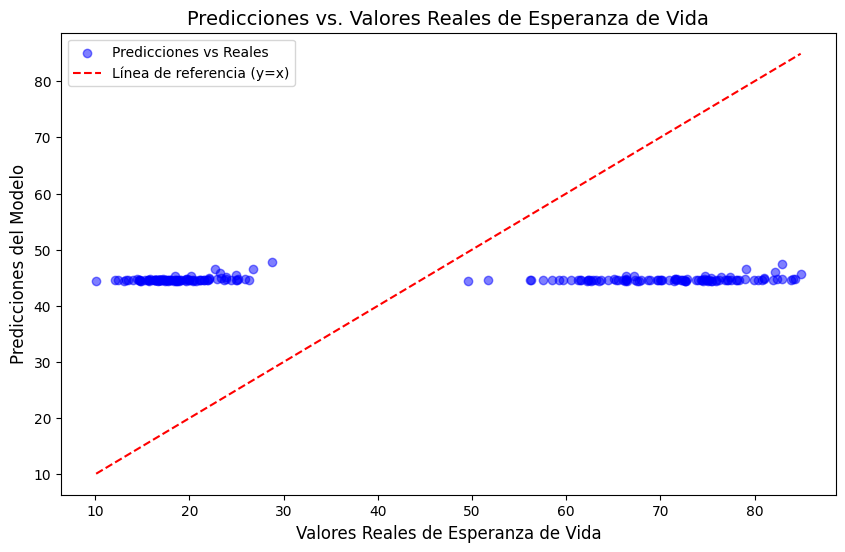

In [39]:
import matplotlib.pyplot as plt

# Graficar los valores reales vs. las predicciones
plt.figure(figsize=(10, 6))

# Graficar valores reales de esperanza de vida
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Predicciones vs Reales')

# Añadir una línea de referencia (y = x) para comparar las predicciones y los valores reales
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Línea de referencia (y=x)')

# Títulos y etiquetas
plt.title('Predicciones vs. Valores Reales de Esperanza de Vida', fontsize=14)
plt.xlabel('Valores Reales de Esperanza de Vida', fontsize=12)
plt.ylabel('Predicciones del Modelo', fontsize=12)

# Añadir leyenda
plt.legend()

# Mostrar el gráfico
plt.show()


In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Suponiendo que 'df_combined' tiene las columnas 'PIB' y 'Dim1'
X = df_combined[['PIB', 'Dim1']]  # Usamos 'Dim1' como la columna de sexo
y = df_combined['Esperanza_de_vida']

# Crear un transformador para 'Dim1' con OneHotEncoder para convertir categorías en variables dummy
preprocessor = ColumnTransformer(
    transformers=[
        ('sex', OneHotEncoder(), ['Dim1'])  # Codificamos 'Dim1' con OneHotEncoder
    ], 
    remainder='passthrough'  # Mantiene otras columnas como están
)

# Crear el modelo de regresión lineal
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar el modelo
model.fit(X_train, y_train)

# Hacer predicciones
y_pred = model.predict(X_test)

# Evaluar el modelo con RMSE y R²
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)


RMSE: 27.002530379813365
R²: 0.007478641146635767


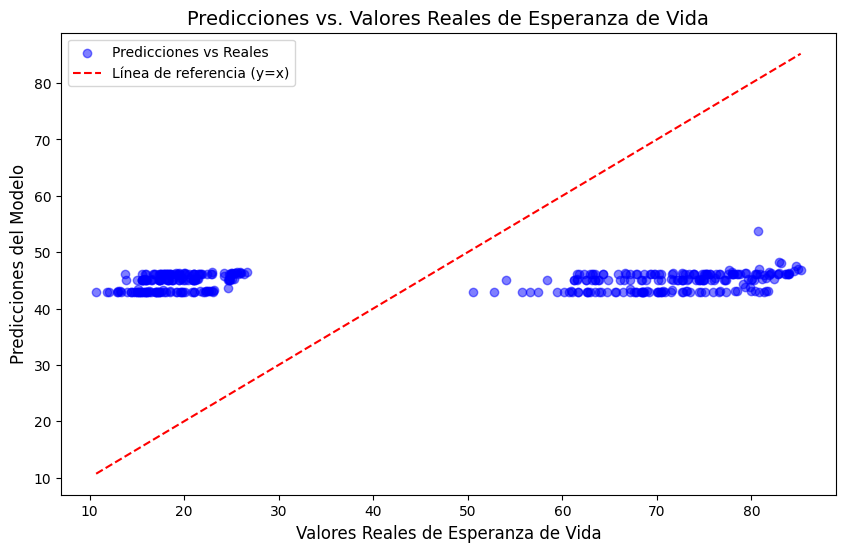

In [ ]:
import matplotlib.pyplot as plt

# Graficar los valores reales vs. las predicciones
plt.figure(figsize=(10, 6))

# Graficar los valores reales de la esperanza de vida (y_test)
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Predicciones vs Reales')

# Añadir una línea de referencia (y = x) para comparar las predicciones y los valores reales
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Línea de referencia (y=x)')

# Títulos y etiquetas
plt.title('Predicciones vs. Valores Reales de Esperanza de Vida', fontsize=14)
plt.xlabel('Valores Reales de Esperanza de Vida', fontsize=12)
plt.ylabel('Predicciones del Modelo', fontsize=12)

# Añadir leyenda
plt.legend()

# Mostrar el gráfico
plt.show()


C:\Users\Equipo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\Equipo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\Equipo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\Equipo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Py

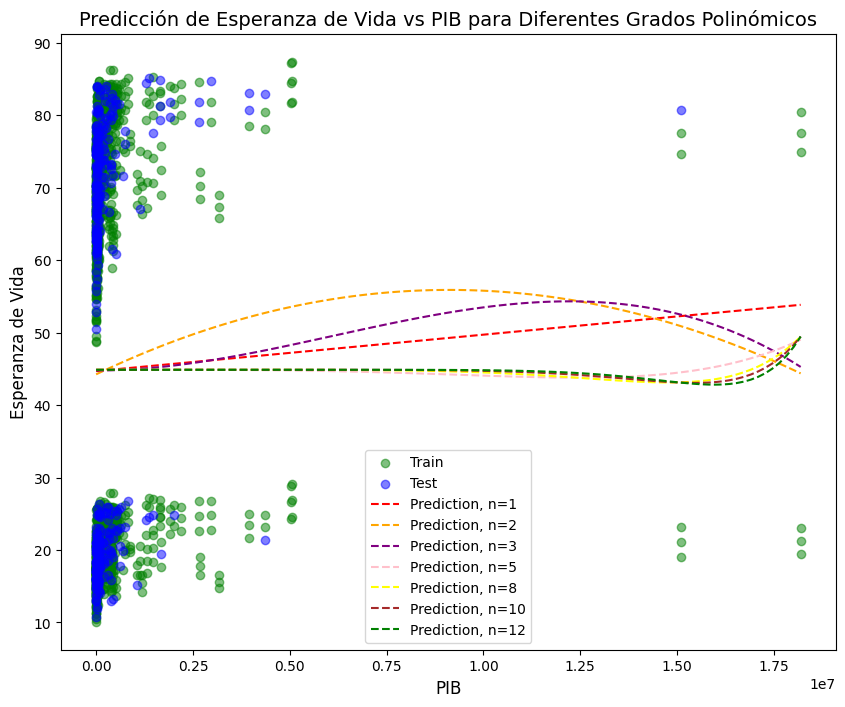

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Suponiendo que ya tienes el DataFrame df_combined con 'PIB' y 'Esperanza_de_vida'
X = df_combined[['PIB']]  # Variable independiente: PIB
y = df_combined['Esperanza_de_vida']  # Variable dependiente: Esperanza de vida

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear el gráfico
plt.figure(figsize=(10, 8))

# Graficar los datos reales de entrenamiento y prueba
plt.scatter(X_train, y_train, color='green', label='Train', alpha=0.5)
plt.scatter(X_test, y_test, color='blue', label='Test', alpha=0.5)

# Definir los grados polinómicos a probar
degrees = [1, 2, 3, 5, 8, 10, 12]
colors = ['red', 'orange', 'purple', 'pink', 'yellow', 'brown', 'green']

# Entrenar y graficar los modelos polinómicos para diferentes grados
for degree, color in zip(degrees, colors):
    # Crear el transformador polinómico para el grado actual
    poly = PolynomialFeatures(degree=degree)
    X_poly_train = poly.fit_transform(X_train)
    X_poly_test = poly.transform(X_test)
    
    # Crear el modelo de regresión lineal
    model = LinearRegression()
    model.fit(X_poly_train, y_train)
    
    # Hacer predicciones en los datos de prueba
    y_pred = model.predict(X_poly_test)
    
    # Graficar la curva de predicción para el grado polinómico
    x_grid = np.linspace(np.min(X), np.max(X), 100).reshape(-1, 1)  # Crear una malla de valores de PIB
    x_poly_grid = poly.transform(x_grid)
    y_poly_pred = model.predict(x_poly_grid)
    
    # Graficar la predicción para este grado
    plt.plot(x_grid, y_poly_pred, linestyle='--', color=color, label=f'Prediction, n={degree}')

# Añadir título, etiquetas y leyenda
plt.title('Predicción de Esperanza de Vida vs PIB para Diferentes Grados Polinómicos', fontsize=14)
plt.xlabel('PIB', fontsize=12)
plt.ylabel('Esperanza de Vida', fontsize=12)
plt.legend()

# Mostrar el gráfico
plt.show()


<Axes: >

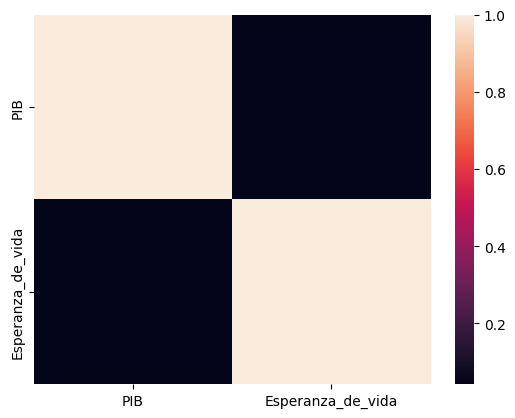

In [ ]:
correlacion = df_combined[['PIB', 'Esperanza_de_vida']].corr()
import seaborn as sns
sns.heatmap(correlacion)